In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import h5py
import pandas as pd
import time
import pickle

colors = ['#21918c', '#b5367a', '#d55e00', '#4b5d67', '#b58900']

In [ ]:
ds = pd.read_hdf('build/events_anomalydetection_Z_XY_qqq.h5')

In [ ]:
ds

,0,1,2,3,4,5,6,7,8,9,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,18.283588,-0.903479,0.060979,3.316431,-0.784941,-0.008755,9.464178,-0.812918,-0.037386,4.578035,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,17.661003,-0.446288,-1.379160,43.478683,-0.458125,-1.373650,208.452606,-0.455308,-1.375457,99.440353,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.624793,-0.677988,0.938955,1.265689,-1.418007,-2.987415,2.943629,-1.171538,2.927404,1.740146,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.337102,-0.576148,-1.488119,0.746461,-0.690281,-1.168585,0.822929,-0.611731,-0.854227,1.700466,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.560168,-0.426791,0.971822,0.522985,-2.214125,0.120384,1.950790,-2.105558,-0.649089,0.402474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.419765,-0.428561,2.483830,0.668431,-0.364857,1.689107,0.596685,-1.094639,1.496762,14.726097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
99996,0.607786,-2.315238,-0.170871,0.361538,-0.018587,0.459475,0.748329,-0.617934,2.282426,0.364542,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
99997,0.889897,-2.390522,-0.387898,0.287380,-1.938891,1.868297,0.401675,-1.804117,1.285600,1.670041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
99998,0.315057,-1.749749,-1.422875,2.182747,-1.920024,2.674101,0.425823,-1.260437,-0.585848,1.348121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


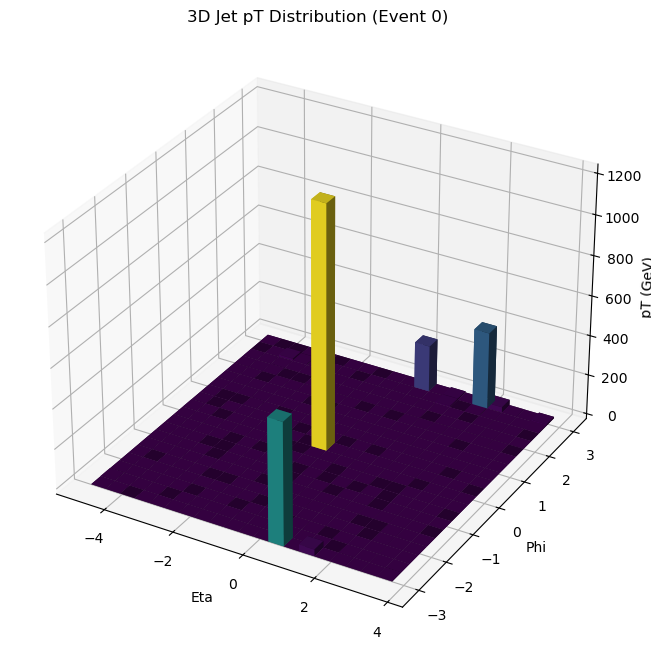

In [59]:
df = pd.read_csv('ReconstructedJet.csv')
event_0 = df[df['EventID'] == 0]

# 2. Calculate the 2D Histogram Data (Heights)
# We use numpy to get the raw numbers for the bin heights
bins = 20
hist, xedges, yedges = np.histogram2d(
   event_0['Eta'], 
   event_0['Phi'], 
   bins=bins, 
   weights=event_0['pT']
)

# 3. Setup the 3D Canvas
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Create the meshgrid for the bars
# Construct arrays for the anchor positions of the bars
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

# Construct arrays for the dimensions of the bars
dx = (xedges[1] - xedges[0]) # 0.8 adds a small gap between bars
dy = (yedges[1] - yedges[0])
dz = hist.ravel()

# 5. Plot the 3D Bars
# We can map the color to the height (pT) for extra aesthetics
colors = plt.cm.viridis(dz / dz.max())

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average')

# 6. Labels and Formatting
ax.set_xlabel('Eta')
ax.set_ylabel('Phi')
ax.set_zlabel('pT (GeV)')
ax.set_title('3D Jet pT Distribution (Event 0)')

plt.show()

# Serial Distributions

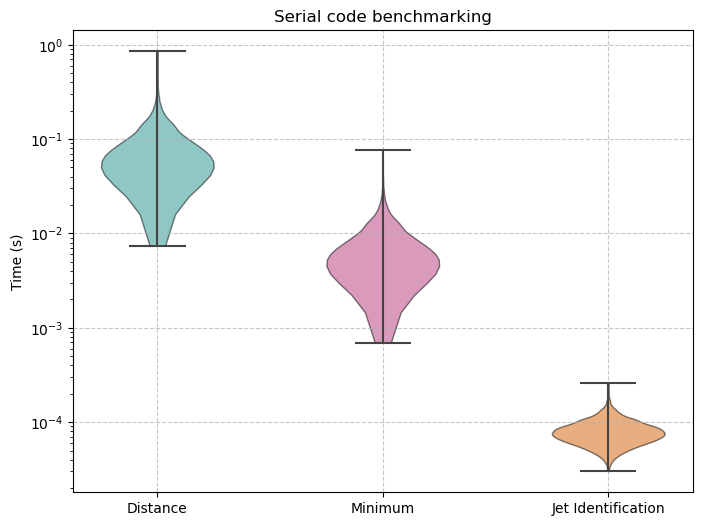

In [51]:
CollisionInfo = pd.read_csv('Benchmarking/Collision.csv')


#Distributions of single events
labels = ['Distance', 'Minimum', 'Jet Identification']


fig, ax = plt.subplots(figsize=(8, 6))

vPlot = ax.violinplot(CollisionInfo.iloc[:, 1:], showmeans=False, showmedians=False, showextrema=True)

for i, pc in enumerate(vPlot['bodies']):
   pc.set_facecolors(colors[i])
   pc.set_edgecolor('black')
   pc.set_alpha(0.5)

line_components = ['cmaxes', 'cmins', 'cbars']
for part in line_components:
    vPlot[part].set_edgecolor("#454444")
    vPlot[part].set_linewidth(1.5)

plt.yscale('log')
plt.xticks(range(1, len(labels) + 1), labels)
plt.title('Serial code benchmarking')
plt.ylabel('Time (s)')

plt.grid(linestyle='--', alpha=0.7)

Text(0.5, 1.0, 'Serial code total time')

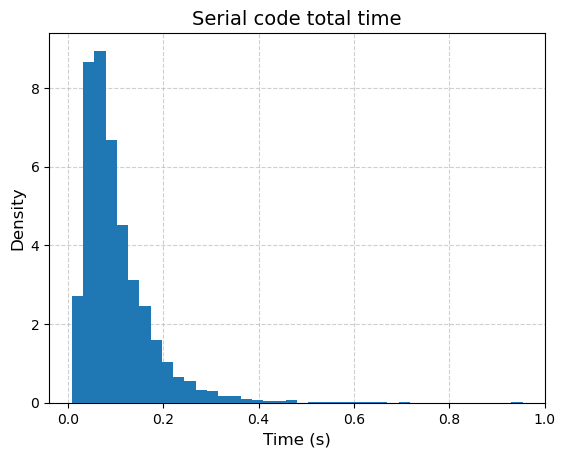

In [54]:
plt.hist(CollisionInfo.iloc[:, 0], bins = 40, density = True, zorder = 100)
plt.grid(True, alpha = 0.6, linestyle = '--')

plt.xlabel("Time (s)", fontsize = 12)
plt.ylabel("Density", fontsize = 12)
plt.title("Serial code total time", fontsize = 14)

# Speedup and Efficiency

In [15]:
!g++ Anti_kt/serialJetClustering.cpp -o serialJetClustering
!clang++ -Xpreprocessor -fopenmp -I/opt/homebrew/opt/libomp/include -L/opt/homebrew/opt/libomp/lib -lomp Anti_kt/directiveJetClustering.cpp -o directiveJetClustering

In [25]:
AnalysisTime = {}
n = 500


#Baseline time
s = time.time()
!./serialJetClustering {n}
e = time.time()

AnalysisTime['Baseline'] = (e-s, 0)
print(f'Baseline: {e-s} s')


#Multiprocessing time
for cores in range(2, 9):

   avgTime = []

   %env OMP_NUM_THREADS=$cores
   for i in range(10):
      s = time.time()
      !./directiveJetClustering {n}
      e = time.time()
      avgTime.append(e-s)

   AnalysisTime[f'nCores={cores}'] = (np.mean(avgTime), np.std(avgTime))
   print(f'nCores = {cores}: {e-s} s')

Baseline: 51.020426988601685 s
env: OMP_NUM_THREADS=2
nCores = 2: 26.24600601196289 s
env: OMP_NUM_THREADS=3
nCores = 3: 19.220057725906372 s
env: OMP_NUM_THREADS=4
nCores = 4: 16.290276050567627 s
env: OMP_NUM_THREADS=5
nCores = 5: 14.930118799209595 s
env: OMP_NUM_THREADS=6
nCores = 6: 13.87551999092102 s
env: OMP_NUM_THREADS=7
nCores = 7: 13.14052414894104 s
env: OMP_NUM_THREADS=8
nCores = 8: 11.81397795677185 s


In [ ]:
# with open('AnalysisTime.pkl', 'wb') as f:
#    pickle.dump(AnalysisTime, f)

In [38]:
[list(AnalysisTime.values())[i][0] for i in range(8)]

[51.020426988601685,
 np.float64(26.315675926208495),
 np.float64(19.371690487861635),
 np.float64(16.202926778793334),
 np.float64(14.909891057014466),
 np.float64(13.76604676246643),
 np.float64(12.989079999923707),
 np.float64(11.938461899757385)]

<ErrorbarContainer object of 3 artists>

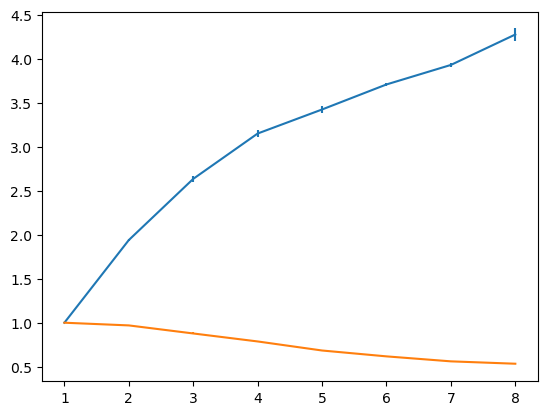

In [51]:
with open('AnalysisTime.pkl', 'rb') as f:
   AnalysisTime = pickle.load(f)


Time = np.array([list(AnalysisTime.values())[i][0] for i in range(8)])
STD  = np.array([list(AnalysisTime.values())[i][1] for i in range(8)])

sSTD = Time[0]/Time**2 * STD

nCores = np.arange(1, 9)
Speedup = Time[0]/Time
Efficiency = Speedup/nCores


plt.errorbar(nCores, Speedup, sSTD)

plt.errorbar(nCores, Efficiency, sSTD/nCores)


# Time complexity

In [ ]:
# !g++ serialJetClustering.cpp -o serialJetClustering
#!g++ -O3 -fopenmp directiveJetClustering.cpp -o directiveJetClustering
# !nvcc cudaJetClustering.cu -o cudaJetClustering

In [ ]:
# BenchmarkTime = {
#    'Serial': [],
#    'Directive': [],
#    'CUDA': []
# }

# for n in numCollision:

#    print(f'Running with N = {n} collisions')

#    s = time.time()
#    !./serialJetClustering {n}
#    e = time.time()

#    diff = e-s
#    BenchmarkTime['Serial'].append(diff)

   # s = time.time()
   # !./directiveJetClustering {n}
   # e = time.time()

   # diff = e-s
   # BenchmarkTime['Directive'].append(diff)
   
   # s = time.time()
   # !./cudaJetClustering {n}
   # e = time.time()

   # diff = e-s
   # BenchmarkTime['CUDA'].append(diff)

Running with N = 10 collisions
Running with N = 25 collisions
Running with N = 50 collisions
Running with N = 75 collisions
Running with N = 100 collisions
Running with N = 250 collisions
Running with N = 500 collisions
Running with N = 750 collisions
Running with N = 1000 collisions
Running with N = 2500 collisions
Running with N = 5000 collisions
Running with N = 7500 collisions
Running with N = 10000 collisions


In [55]:
numCollision = [10, 25, 50, 75, 100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000] #25000, 50000, 75000, 100000]


with open('BenchmarkTime.pkl', 'rb') as f:
   BenchmarkTime = pickle.load(f)

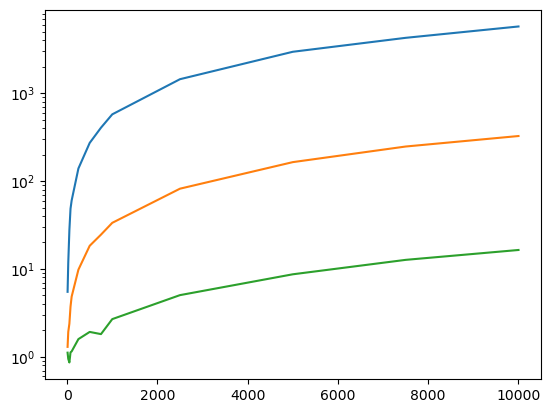

In [54]:
plt.plot(numCollision, BenchmarkTime['Serial'])
plt.plot(numCollision, BenchmarkTime['Directive'])
plt.plot(numCollision, BenchmarkTime['CUDA'])


plt.yscale('log')
#plt.xscale('log')



## Time Complexity

In [2]:
!g++ Anti_kt/serialJetClustering.cpp -o serialJetClustering
!g++ LinkedCell/LC_serialJC.cpp -o LC_serialJC

In [ ]:
n = 500
nColl = np.arange(10, 600, 20)

TimeComplexity = {
   'Antik_T' : [],
   'FastJet' : []
}

for c in nColl:
   print(f"Analyzing {c} collision")
   a = []
   f = []
   for i in range(2):

      s = time.time()
      !./serialJetClustering {n} {c}
      e = time.time()
      a.append(e-s)

      s = time.time()
      !./LC_serialJC {n} {c}
      e = time.time()
      f.append(e-s)

   TimeComplexity['Antik_T'].append(np.mean(a))
   TimeComplexity['FastJet'].append(np.mean(f))


Analyzing 10 collision
Analyzing 30 collision
Analyzing 50 collision
Analyzing 70 collision
Analyzing 90 collision
Analyzing 110 collision
Analyzing 130 collision
Analyzing 150 collision
Analyzing 170 collision
Analyzing 190 collision
Analyzing 210 collision
Analyzing 230 collision
Analyzing 250 collision
Analyzing 270 collision
Analyzing 290 collision
Analyzing 310 collision
Analyzing 330 collision
Analyzing 350 collision
Analyzing 370 collision
Analyzing 390 collision
Analyzing 410 collision
Analyzing 430 collision
Analyzing 450 collision
Analyzing 470 collision
Analyzing 490 collision
Analyzing 510 collision
Analyzing 530 collision
Analyzing 550 collision
Analyzing 570 collision
Analyzing 590 collision


In [7]:
TimeComplexity

{'Antik_T': [(np.float64(0.2904089689254761),
   np.float64(0.008198857307434082)),
  (np.float64(0.5948203802108765), np.float64(0.000708460807800293)),
  (np.float64(1.5205744504928589), np.float64(0.016617417335510254)),
  (np.float64(3.57862651348114), np.float64(0.021367669105529785)),
  (np.float64(7.112997889518738), np.float64(0.016665101051330566)),
  (np.float64(12.337238550186157), np.float64(0.012460708618164062)),
  (np.float64(17.659159183502197), np.float64(0.017550945281982422)),
  (np.float64(21.090503931045532), np.float64(0.05633711814880371)),
  (np.float64(18.710171103477478), np.float64(0.13710391521453857)),
  (np.float64(15.341851472854614), np.float64(0.025884389877319336)),
  (np.float64(9.741896152496338), np.float64(0.010067939758300781)),
  (np.float64(6.528433561325073), np.float64(0.02584052085876465)),
  (np.float64(4.667641997337341), np.float64(0.02808511257171631)),
  (np.float64(3.202863931655884), np.float64(0.019707918167114258)),
  (np.float64(2.3

In [ ]:
A_Time = np.array([list(TimeComplexity['Antik_T'].values)[i][0] for i in range(len(nColl))])
F_Time = np.array([list(TimeComplexity['FastJet'].values)[i][0] for i in range(len(nColl))])


plt.plot(nColl, A_Time)
plt.plot(nColl, F_Time)